# Community Detection and Community Analysis on Reddit Network

This notebook focuses on detecting and analyzing communities inside the Reddit hyperlink network.

The main goals are:

- Detect subreddit communities using Louvain and Girvan-Newman algorithms.
- Measure community quality using modularity.
- Analyze community size and density.
- Detect polarized and bridge communities.
- Visualize community structures using graph plots and interactive graphs.

The Reddit network represents interactions between subreddits, where:
- nodes represent subreddits,
- edges represent hyperlinks or references between communities.

## 1. Import Required Libraries

In this section, we import the libraries used for:

- graph analysis,
- community detection,
- visualization,
- and data processing.

NetworkX is used for graph operations, while python-louvain is used for scalable community detection.

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

from networkx.algorithms.community import (
    girvan_newman,
    greedy_modularity_communities,
    modularity
)

from pyvis.network import Network
import community as community_louvain

import itertools

## 2. Load the Reddit Network Graph

The graph was previously constructed during the preprocessing and network analysis phases.

In [4]:
GRAPH_PATH = 'data/processed/directed_graph.graphml'

G_directed = nx.read_graphml(GRAPH_PATH)

print('Directed graph loaded successfully.')
print(f'Nodes: {G_directed.number_of_nodes()}')
print(f'Edges: {G_directed.number_of_edges()}')

Directed graph loaded successfully.
Nodes: 35777
Edges: 137821


## 3. Convert Graph to Undirected Network

Community detection algorithms are generally more effective on undirected graphs because they focus on grouping highly connected nodes regardless of edge direction.

For this reason, the directed Reddit graph is converted into an undirected graph before analysis.

In [5]:
G_undirected = G_directed.to_undirected()

print('Converted to undirected graph.')
print(f'Nodes: {G_undirected.number_of_nodes()}')
print(f'Edges: {G_undirected.number_of_edges()}')

Converted to undirected graph.
Nodes: 35777
Edges: 124330


## 4. Louvain Community Detection

The Louvain algorithm is one of the most efficient methods for detecting communities in large-scale networks.

The algorithm groups subreddits into communities by maximizing modularity, which measures how strongly nodes are connected inside communities compared to outside communities.

In [6]:
print('Running Louvain community detection...')

louvain_labels = community_louvain.best_partition(G_undirected)

print(f'Total communities detected: {len(set(louvain_labels.values()))}')

Running Louvain community detection...
Total communities detected: 550


## 5. Convert Community Labels into Community Lists

The Louvain algorithm returns a dictionary where each node is assigned a community label.

In this section, the labels are converted into lists of communities to simplify later analysis and metric calculations.

In [7]:
def partition_to_communities(partition_dict):
    communities = {}

    for node, label in partition_dict.items():
        communities.setdefault(label, []).append(node)

    return list(communities.values())


louvain_communities = partition_to_communities(louvain_labels)

## 6. Compute Modularity Score

Modularity is used to evaluate the quality of detected communities.

A higher modularity score indicates stronger separation between communities and denser internal connections.

In [8]:
louvain_modularity = modularity(
    G_undirected,
    louvain_communities
)

print(f'Modularity Score: {louvain_modularity:.4f}')

Modularity Score: 0.5109


## 7. Community Statistics and Density Analysis

This section computes important statistics for each detected community, including:

- community size,
- internal density,
- and structural characteristics.

Community density measures how strongly nodes are connected inside the same community.

In [9]:
def community_density(G, nodes):
    n = len(nodes)

    if n < 2:
        return 0.0

    sub = G.subgraph(nodes)

    possible_edges = n * (n - 1) / 2

    return sub.number_of_edges() / possible_edges

In [10]:
community_stats = []

for idx, nodes in enumerate(louvain_communities):

    density = community_density(G_undirected, nodes)

    community_stats.append({
        'community_id': idx,
        'size': len(nodes),
        'density': density
    })

community_stats_df = pd.DataFrame(community_stats)

community_stats_df.sort_values(
    by='size',
    ascending=False,
    inplace=True
)

community_stats_df.head()

,community_id,size,density
7,7,5299,0.001238
5,5,4868,0.000908
1,1,4492,0.001299
11,11,3007,0.001592
13,13,2189,0.001480


## 8. Analyze Largest Communities

The largest communities are inspected to better understand the structure of the Reddit network and identify dominant subreddit groups.

In [24]:
print('Top 10 Largest Communities')

community_stats_df.head(10)

Top 10 Largest Communities


,community_id,size,density
7,7,5299,0.001238
5,5,4868,0.000908
1,1,4492,0.001299
11,11,3007,0.001592
13,13,2189,0.001480
2,2,1799,0.002927
12,12,1613,0.001885
8,8,1167,0.003335
4,4,1137,0.002710
6,6,992,0.003713


## 9. Statistical Summary of Communities

This section provides descriptive statistics for community sizes and densities, including:

- mean,
- standard deviation,
- minimum and maximum values,
- and quartile distributions.

In [25]:
print('Community Statistics Summary')

community_stats_df.describe()

Community Statistics Summary


,community_id,size,density
count,550.000000,550.000000,550.000000
mean,274.500000,65.049091,0.886372
std,158.915596,421.555035,0.272357
min,0.000000,2.000000,0.000908
25%,137.250000,2.000000,1.000000
50%,274.500000,2.000000,1.000000
75%,411.750000,2.000000,1.000000
max,549.000000,5299.000000,1.000000


## 10. Community Size Distribution

The distribution of community sizes is visualized to understand how communities are spread across the network.

Social networks usually contain:
- many small communities,
- and a few very large communities.

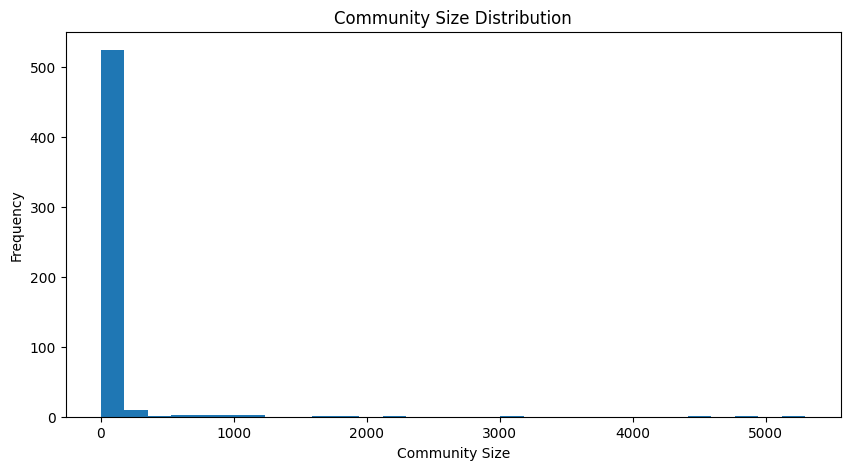

In [26]:
plt.figure(figsize=(10, 5))

plt.hist(
    community_stats_df['size'],
    bins=30
)

plt.title('Community Size Distribution')

plt.xlabel('Community Size')

plt.ylabel('Frequency')

plt.show()

## 11. Save Community Detection Results

The detected community labels and modularity results are exported as CSV files for later analysis and integration with other project components.

In [12]:
community_labels_df = pd.DataFrame({
    'node': list(louvain_labels.keys()),
    'community': list(louvain_labels.values())
})

community_labels_df.to_csv(
    'results/community_labels.csv',
    index=False
)

print('Saved community_labels.csv')

Saved community_labels.csv


# Save Modularity Results

In [13]:
modularity_results = pd.DataFrame([{
    'algorithm': 'Louvain',
    'modularity': louvain_modularity,
    'num_communities': len(louvain_communities)
}])

modularity_results.to_csv(
    'results/modularity_results.csv',
    index=False
)

print('Saved modularity_results.csv')

Saved modularity_results.csv


## 12. Girvan-Newman Community Detection

The Girvan-Newman algorithm detects communities by progressively removing important edges from the network.

Because the Reddit network is very large, the algorithm is applied only on a sampled subgraph due to its high computational complexity.

In [14]:
largest_component = max(
    nx.connected_components(G_undirected),
    key=len
)

G_core = G_undirected.subgraph(largest_component).copy()

sample_nodes = list(G_core.nodes())[:150]

G_small = G_core.subgraph(sample_nodes).copy()

print(f'Sampled graph nodes: {G_small.number_of_nodes()}')

Sampled graph nodes: 150


In [15]:
communities_generator = girvan_newman(G_small)

top_level_communities = next(communities_generator)

gn_communities = [list(c) for c in top_level_communities]

gn_modularity = modularity(G_small, gn_communities)

print(f'Girvan-Newman modularity: {gn_modularity:.4f}')

Girvan-Newman modularity: 0.0049


## 13. Polarized Community Detection

Polarized communities are identified as groups with:

- relatively high internal density,
- and sufficiently large size.

These communities may represent tightly connected subreddit groups with limited external interaction.

In [23]:
polarized = community_stats_df[
    (community_stats_df['density'] > 0.001) &
    (community_stats_df['size'] > 100)
]

polarized.head()

,community_id,size,density
7,7,5299,0.001238
1,1,4492,0.001299
11,11,3007,0.001592
13,13,2189,0.001480
2,2,1799,0.002927


## 14. Bridge Community Analysis

Bridge communities are communities containing nodes with high betweenness centrality.

Such communities may act as connectors between different parts of the network and can play an important role in information or toxicity propagation.

# Load Centrality Results

In [28]:
centrality_df = pd.read_csv('results/centrality_results.csv')

centrality_df.head()

,Subreddit Node,In-Degree Centrality,Out-Degree Centrality,Total Degree Centrality,Betweenness Centrality,Closeness Centrality
0,askreddit,0.060404,0.010146,0.070550,0.052596,0.313949
1,subredditdrama,0.012690,0.037735,0.050425,0.049401,0.262502
2,iama,0.046008,0.010733,0.056742,0.044142,0.304570
3,outoftheloop,0.016547,0.014172,0.030719,0.028853,0.272173
4,writingprompts,0.020041,0.011907,0.031949,0.017028,0.256204


# Rename Column for Merge

In [29]:
centrality_df.rename(
    columns={'Subreddit Node': 'node'},
    inplace=True
)

# Merge with Community Labels

In [30]:
community_labels_df = pd.DataFrame({
    'node': list(louvain_labels.keys()),
    'community': list(louvain_labels.values())
})

merged_df = pd.merge(
    community_labels_df,
    centrality_df,
    on='node',
    how='left'
)

merged_df.head()

,node,community,In-Degree Centrality,Out-Degree Centrality,Total Degree Centrality,Betweenness Centrality,Closeness Centrality
0,leagueoflegends,0,0.016128,0.007156,0.023284,0.012104,0.261240
1,teamredditteams,0,0.000112,0.000307,0.000419,0.000041,0.192273
2,theredlion,1,0.000056,0.000531,0.000587,0.000008,0.179299
3,soccer,2,0.008190,0.003075,0.011265,0.004692,0.249464
4,inlandempire,3,0.000084,0.000168,0.000252,0.000045,0.197519


# Compute Bridge Scores Per Community

In [31]:
bridge_communities = merged_df.groupby('community')[
    'Betweenness Centrality'
].mean().reset_index()

bridge_communities.rename(
    columns={
        'Betweenness Centrality': 'avg_betweenness'
    },
    inplace=True
)

bridge_communities.sort_values(
    by='avg_betweenness',
    ascending=False,
    inplace=True
)

print('Top Bridge Communities')

bridge_communities.head(10)

Top Bridge Communities


,community,avg_betweenness
22,22,0.000152
12,12,0.000051
1,1,0.000049
7,7,0.000048
43,43,0.000042
86,86,0.000042
5,5,0.000037
11,11,0.000036
0,0,0.000035
25,25,0.000034


## 15. Community Visualization

A sampled subgraph is visualized using NetworkX and matplotlib.

Nodes are colored according to their detected Louvain community to illustrate the overall community structure of the Reddit network.

Visualization graph nodes: 300


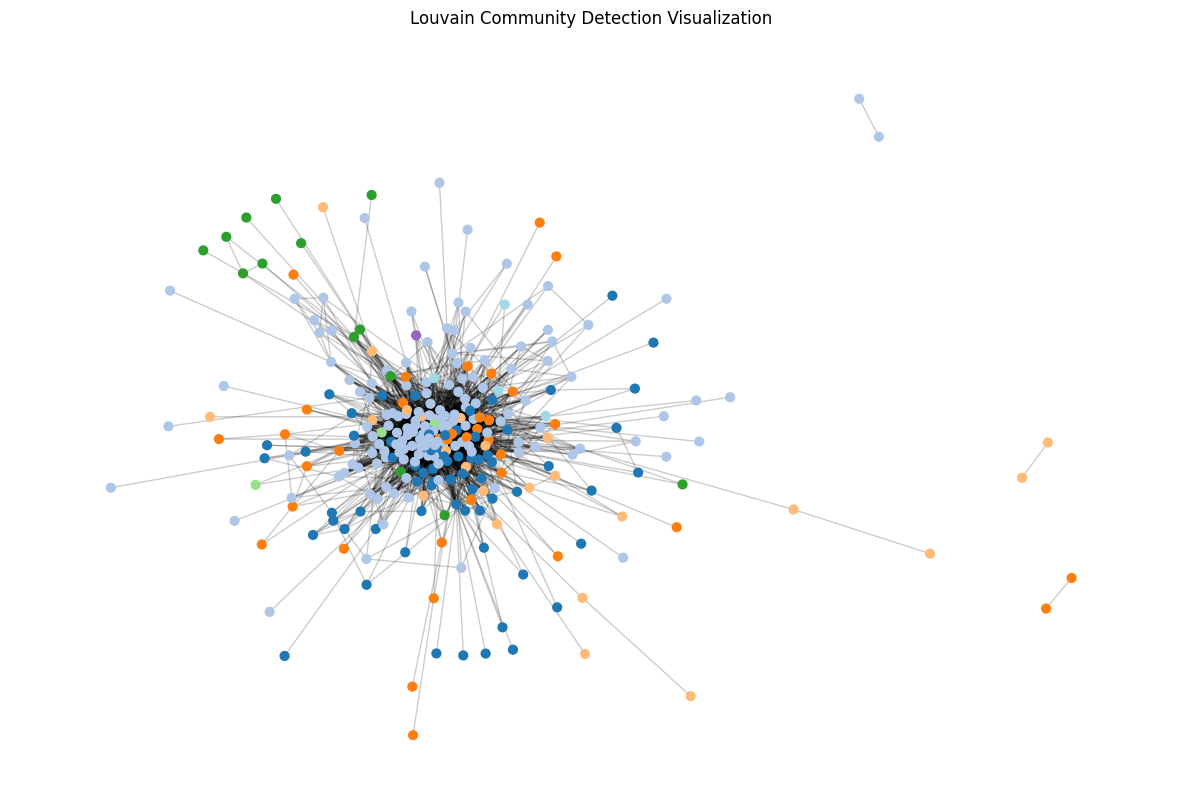

In [49]:
## Create Visualization Subgraph

largest_component = max(
    nx.connected_components(G_undirected),
    key=len
)

G_core = G_undirected.subgraph(largest_component)

sample_nodes = list(G_core.nodes())[:300]

G_vis = G_core.subgraph(sample_nodes).copy()

print(f'Visualization graph nodes: {G_vis.number_of_nodes()}')

vis_partition = {
    node: louvain_labels[node]
    for node in G_vis.nodes()
}

plt.figure(figsize=(15, 10))

pos = nx.spring_layout(
    G_vis,
    seed=42,
    k=0.15
)

nx.draw_networkx_nodes(
    G_vis,
    pos,
    node_size=40,
    node_color=list(vis_partition.values()),
    cmap=plt.cm.tab20
)

nx.draw_networkx_edges(
    G_vis,
    pos,
    alpha=0.2
)

plt.title('Louvain Community Detection Visualization')

plt.axis('off')

plt.savefig(
    'visualizations/community_detection.png',
    bbox_inches='tight',
    dpi=300
)


plt.show()

## 16. Interactive Community Visualization using PyVis

An interactive network visualization is generated using PyVis.

This allows exploration of subreddit communities and their relationships through a browser-based interactive graph.

In [47]:
net = Network(
    height='750px',
    width='100%',
    bgcolor='#222222',
    font_color='white'
)

## Add Nodes
for node in G_vis.nodes():

    community_id = louvain_labels[node]

    net.add_node(
        node,
        label=node,
        group=community_id
    )

## Add Edges 
for source, target in G_vis.edges():

    net.add_edge(source, target)

## Generate Interactive HTML

net.write_html(
    'visualizations/community_network.html'
)

print('Interactive graph saved.')


Interactive graph saved.


# Conclusion

The Reddit network shows strong community structure with a high modularity score.

The Louvain algorithm successfully detected large-scale subreddit communities, while Girvan-Newman was demonstrated on a smaller sampled graph due to computational limitations.

The analysis also identified:
- polarized communities,
- bridge communities,
- and structural differences between subreddit groups.

These results provide useful insights into how online communities organize and interact inside large social platforms.